In [ ]:
!pip install wordcloud

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv('/content/Tweets.csv')

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [ ]:
df = df[df['airline_sentiment'] != 'neutral']

df['airline_sentiment'].value_counts()

,count
airline_sentiment,
negative,9178
positive,2363


In [ ]:
df = df[['text', 'airline_sentiment']]

df.head()

,text,airline_sentiment
1,@VirginAmerica plus you've added commercials t...,positive
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative
5,@VirginAmerica seriously would pay $30 a fligh...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",positive


In [ ]:
df['airline_sentiment'] = df['airline_sentiment'].map({
    'negative': 0,
    'positive': 1
})

df.head()

,text,airline_sentiment
1,@VirginAmerica plus you've added commercials t...,1
3,@VirginAmerica it's really aggressive to blast...,0
4,@VirginAmerica and it's a really big bad thing...,0
5,@VirginAmerica seriously would pay $30 a fligh...,0
6,"@VirginAmerica yes, nearly every time I fly VX...",1


In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
def clean_text(text):

    # convert to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+', '', text)

    # remove mentions (@username)
    text = re.sub(r'@\w+', '', text)

    # remove hashtags
    text = re.sub(r'#\w+', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = text.strip()

    # remove stopwords
    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
df['cleaned_text'] = df['text'].apply(clean_text)

df.head()

,text,airline_sentiment,cleaned_text
1,@VirginAmerica plus you've added commercials t...,1,plus youve added commercials experience tacky
3,@VirginAmerica it's really aggressive to blast...,0,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,0,really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,0,seriously would pay flight seats didnt playing...
6,"@VirginAmerica yes, nearly every time I fly VX...",1,yes nearly every time fly vx “ear worm” won’t ...


In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text'])

y = df['airline_sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
lr_predictions = lr_model.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_predictions))

print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy:
0.8982243395409268

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1862
           1       0.90      0.53      0.67       447

    accuracy                           0.90      2309
   macro avg       0.90      0.76      0.81      2309
weighted avg       0.90      0.90      0.89      2309



In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
nb_predictions = nb_model.predict(X_test)

In [ ]:
print("Naive Bayes Accuracy:")
print(accuracy_score(y_test, nb_predictions))

print("\nClassification Report:")
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy:
0.880900822867042

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1862
           1       0.95      0.40      0.57       447

    accuracy                           0.88      2309
   macro avg       0.91      0.70      0.75      2309
weighted avg       0.89      0.88      0.86      2309



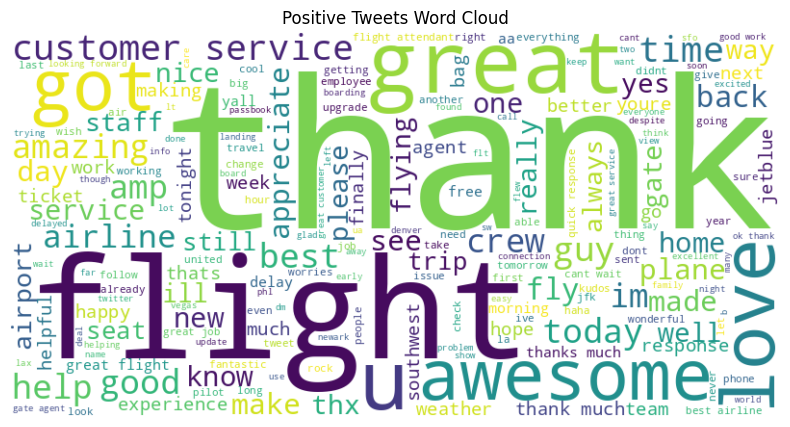

In [ ]:
positive_words = " ".join(df[df['airline_sentiment'] == 1]['cleaned_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Tweets Word Cloud")
plt.show()

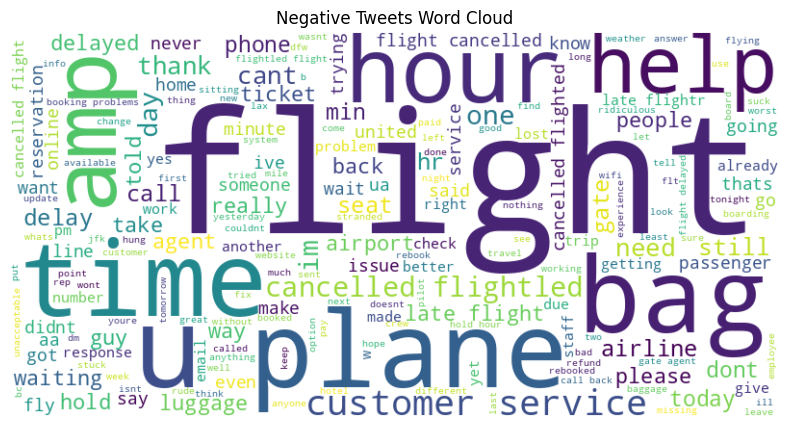

In [ ]:
negative_words = " ".join(df[df['airline_sentiment'] == 0]['cleaned_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Tweets Word Cloud")
plt.show()

In [ ]:
def predict_sentiment(text):

    # clean text
    cleaned = clean_text(text)

    # convert to TF-IDF vector
    vector = tfidf.transform([cleaned])

    # predict using Logistic Regression
    prediction = lr_model.predict(vector)[0]

    if prediction == 1:
        return "Positive 😊"
    else:
        return "Negative 😡"

In [1]:
predict_sentiment("thank you for your help")

NameError: name 'predict_sentiment' is not defined